# CHURNGUARD AI

## Customer Churn Prediction & Retention Intelligence System

### Q1. What is customer churn?

Customer churn means a customer stops using a company's product or service.
In this project, churn means that a customer leaves the company or cancels the service.

### Q2. Why would a company want to predict churn?

A company wants to predict customer churn because:

1. It can identify customers who may leave.
2. It can take action to retain those customers.
3. It can reduce customer loss and improve customer retention.
4. It can provide special offers or better services to customers at risk of leaving.

### Q3. What is the target variable?

The target variable is the "Churn" column.
It tells us whether a customer has left the company or not.

### Q4. Is this a classification or regression problem?

This is a classification problem because the model predicts categories such as "Yes" or "No".
The model will predict whether a customer will churn or stay.

### Q5. What would a false negative mean in this business problem?

A false negative means that the model predicts that a customer will stay,
but the customer actually leaves the company.

This can be important because the company may miss the opportunity to retain that customer.

In [2]:
# Download the IBM Telco Customer Churn dataset

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (7043, 21)


In [4]:
# Display the first 5 rows

display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# Check for missing values in each column

missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values)

Missing values in each column:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
# Check for duplicate customer records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [8]:
# Convert TotalCharges into numeric format
# Invalid values will be converted to NaN

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values after conversion
print("Missing TotalCharges values:", df["TotalCharges"].isnull().sum())

Missing TotalCharges values: 11


In [9]:
# Remove rows where TotalCharges is missing

df = df.dropna(subset=["TotalCharges"])

print("Dataset shape after cleaning:", df.shape)
print("Remaining missing TotalCharges values:", df["TotalCharges"].isnull().sum())

Dataset shape after cleaning: (7032, 21)
Remaining missing TotalCharges values: 0


In [10]:
# Check customer churn distribution

churn_counts = df["Churn"].value_counts()

print("Customer Churn Distribution:")
display(churn_counts)

Customer Churn Distribution:


,count
Churn,
No,5163
Yes,1869


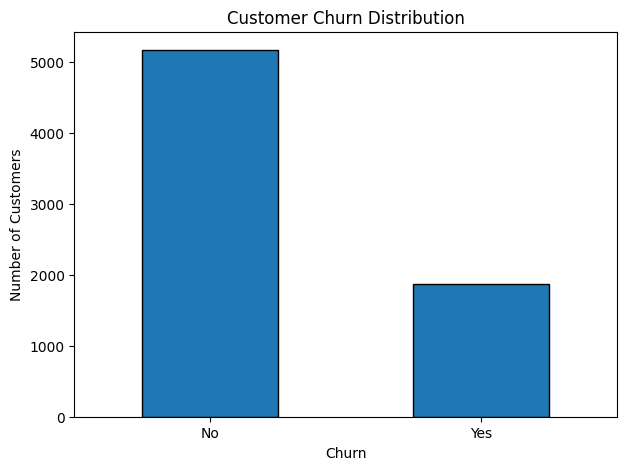

In [11]:
# Visualize customer churn distribution

plt.figure(figsize=(7, 5))

df["Churn"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [12]:
# Analyze churn by contract type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"]
)

print("Churn by Contract Type:")
display(contract_churn)

Churn by Contract Type:


Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


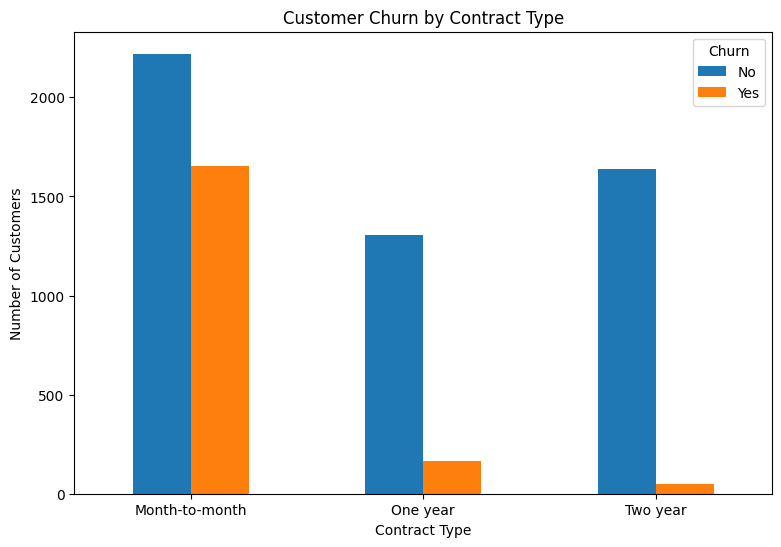

In [13]:
# Visualize churn by contract type

contract_churn.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [14]:
# Compare customer tenure for churned and non-churned customers

tenure_churn = df.groupby("Churn")["tenure"].mean()

print("Average customer tenure by churn status:")
display(tenure_churn)

Average customer tenure by churn status:


,tenure
Churn,
No,37.650010
Yes,17.979133


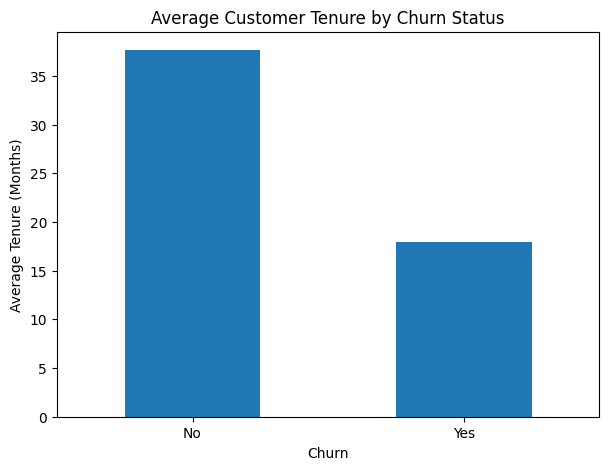

In [15]:
# Visualize average tenure by churn status

tenure_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)")
plt.xticks(rotation=0)

plt.show()

In [16]:
# Compare average monthly charges for churned and non-churned customers

monthly_charges_churn = df.groupby("Churn")["MonthlyCharges"].mean()

print("Average Monthly Charges by Churn Status:")
display(monthly_charges_churn)

Average Monthly Charges by Churn Status:


,MonthlyCharges
Churn,
No,61.307408
Yes,74.441332


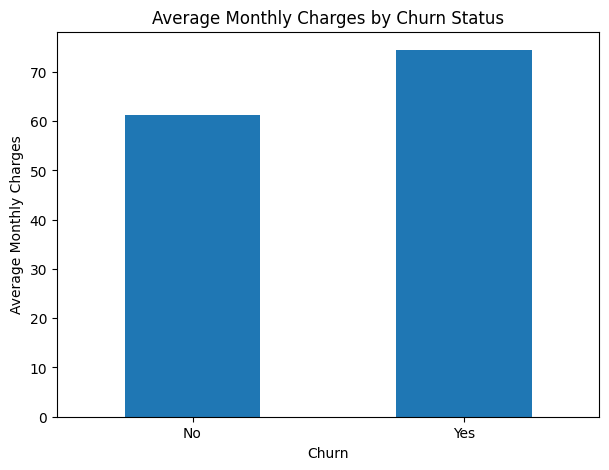

In [17]:
# Visualize average monthly charges by churn status

monthly_charges_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)

plt.show()

In [18]:
# Analyze churn by internet service type

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

print("Churn by Internet Service:")
display(internet_churn)

Churn by Internet Service:


Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [3]:
# Visualize churn by internet service

internet_churn.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

NameError: name 'internet_churn' is not defined

In [4]:
# Churn by Internet Service

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

print("Churn by Internet Service:")
display(internet_churn)

NameError: name 'pd' is not defined

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Check that dataset is available
print("Dataset shape:", df.shape)

# Create churn table directly
internet_churn = pd.crosstab(df["InternetService"], df["Churn"])

print("Churn by Internet Service:")
display(internet_churn)

# Create graph
internet_churn.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

NameError: name 'df' is not defined

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (7043, 21)


In [7]:
# Convert TotalCharges into numeric values
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Missing TotalCharges values:", df["TotalCharges"].isnull().sum())

Missing TotalCharges values: 11


In [8]:
# Remove rows where TotalCharges is missing
df = df.dropna(subset=["TotalCharges"])

print("Dataset shape after cleaning:", df.shape)
print("Remaining missing TotalCharges values:", df["TotalCharges"].isnull().sum())

Dataset shape after cleaning: (7032, 21)
Remaining missing TotalCharges values: 0


Churn by Internet Service:


Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


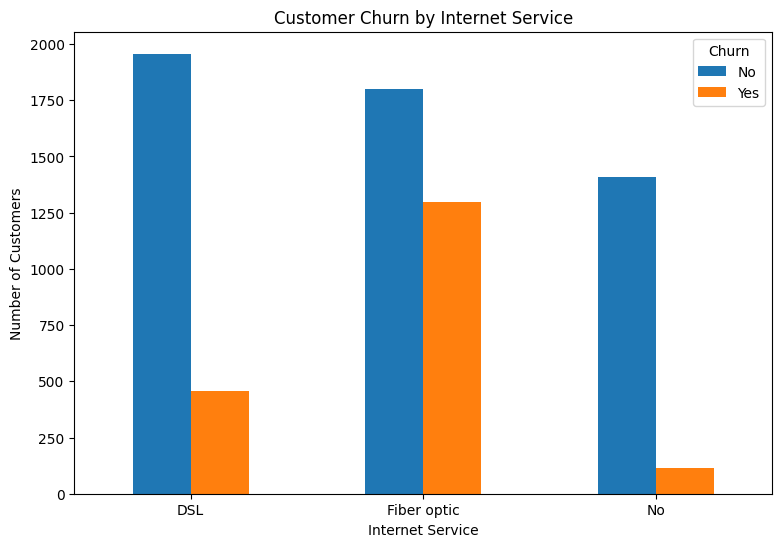

In [9]:
# Churn by Internet Service

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

print("Churn by Internet Service:")
display(internet_churn)

# Graph
internet_churn.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

In [10]:
# Calculate churn percentage

churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print("Churn Percentage:")
display(churn_percentage.round(2))

Churn Percentage:


,proportion
Churn,
No,73.42
Yes,26.58


In [11]:
# Prepare data for Machine Learning

# Remove customer ID because it is only an identifier
X = df.drop(columns=["Churn", "customerID"])

# Target variable
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (7032, 19)
Target shape: (7032,)

Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (5625, 19)
Testing data shape: (1407, 19)
Training target shape: (5625,)
Testing target shape: (1407,)


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Find categorical and numerical columns
categorical_features = X.select_dtypes(
    include=["object"]
).columns

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns

print("Categorical columns:", len(categorical_features))
print("Numerical columns:", len(numerical_features))

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Categorical columns: 15
Numerical columns: 4
Preprocessing pipeline created successfully!


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
# Make predictions on test data

y_pred_logistic = logistic_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_logistic))

Predictions generated successfully!
Number of predictions: 1407


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", round(accuracy_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall   :", round(recall_logistic, 4))
print("F1-Score :", round(f1_logistic, 4))

Logistic Regression Performance
--------------------------------
Accuracy : 0.8017
Precision: 0.6444
Recall   : 0.5668
F1-Score : 0.6031


Confusion Matrix:
[[916 117]
 [162 212]]


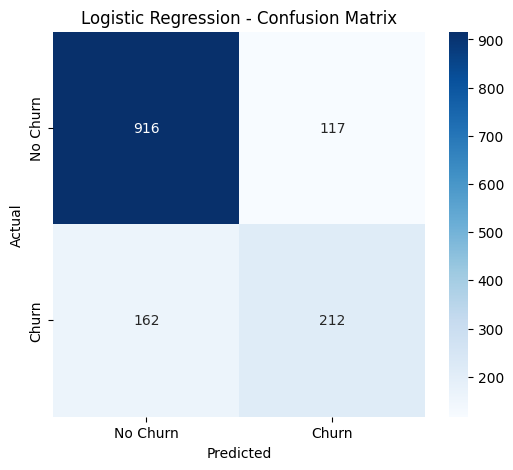

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm_logistic)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Create Random Forest pipeline
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [19]:
# Make predictions using Random Forest

y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions generated successfully!")
print("Number of predictions:", len(y_pred_rf))

Random Forest predictions generated successfully!
Number of predictions: 1407


In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1-Score :", round(f1_rf, 4))

Random Forest Performance
-------------------------
Accuracy : 0.7882
Precision: 0.6275
Recall   : 0.5
F1-Score : 0.5565


Confusion Matrix:
[[922 111]
 [187 187]]


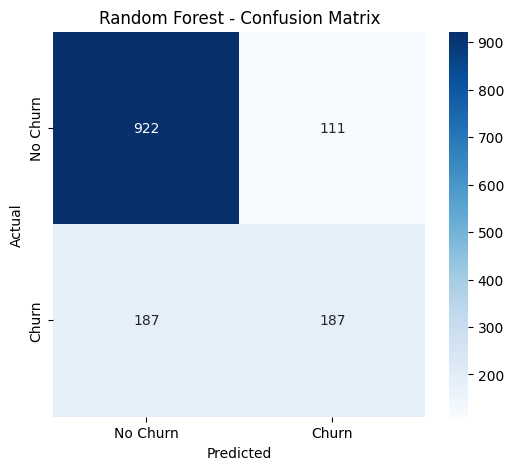

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [22]:
# Compare both machine learning models

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf
    ],
    "Precision": [
        precision_logistic,
        precision_rf
    ],
    "Recall": [
        recall_logistic,
        recall_rf
    ],
    "F1-Score": [
        f1_logistic,
        f1_rf
    ]
})

print("Model Comparison")
display(model_comparison.round(4))

Model Comparison


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8017,0.6444,0.5668,0.6031
1,Random Forest,0.7882,0.6275,0.5000,0.5565


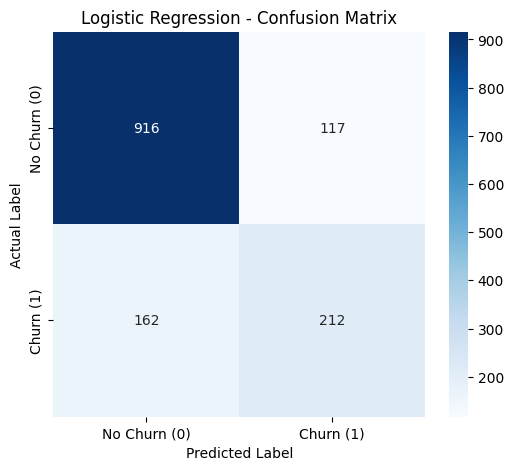

In [23]:
# STEP 13: Confusion Matrix for Selected Model (Logistic Regression)
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions for Logistic Regression
best_predictions = logistic_model.predict(X_test)

# Confusion Matrix Calculate karna
cm = confusion_matrix(y_test, best_predictions)

# Plotting Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn (0)', 'Churn (1)'],
            yticklabels=['No Churn (0)', 'Churn (1)'])

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [24]:
# STEP 14: Customer Prediction Function
import pandas as pd

def predict_customer(customer_data):
    # Customer data ko DataFrame me convert karna
    customer_df = pd.DataFrame([customer_data])

    # Model prediction aur probability calculate karna
    prediction = logistic_model.predict(customer_df)[0]
    probability = logistic_model.predict_proba(customer_df)[0][1]

    # Risk Level set karna
    if probability >= 0.70:
        risk = "HIGH"
    elif probability >= 0.40:
        risk = "MEDIUM"
    else:
        risk = "LOW"

    return {
        'Predicted_Churn': "YES" if prediction == 1 else "NO",
        'Churn_Probability': f"{round(probability * 100, 2)}%",
        'Risk_Level': risk
    }

# Sample Customer Test
sample_customer = X_test.iloc[0].to_dict()
result = predict_customer(sample_customer)

print("--- Sample Customer Prediction ---")
for key, value in result.items():
    print(f"{key}: {value}")

--- Sample Customer Prediction ---
Predicted_Churn: NO
Churn_Probability: 1.82%
Risk_Level: LOW


# STEP 14: Customer Prediction Function
import pandas as pd

def predict_customer(customer_data):
    # Customer data ko DataFrame me convert karna
    customer_df = pd.DataFrame([customer_data])
    
    # Model prediction aur probability calculate karna
    prediction = logistic_model.predict(customer_df)[0]
    probability = logistic_model.predict_proba(customer_df)[0][1]
    
    # Risk Level set karna
    if probability >= 0.70:
        risk = "HIGH"
    elif probability >= 0.40:
        risk = "MEDIUM"
    else:
        risk = "LOW"
        
    return {
        'Predicted_Churn': "YES" if prediction == 1 else "NO",
        'Churn_Probability': f"{round(probability * 100, 2)}%",
        'Risk_Level': risk
    }

# Sample Customer Test
sample_customer = X_test.iloc[0].to_dict()
result = predict_customer(sample_customer)

print("--- Sample Customer Prediction ---")
for key, value in result.items():
    print(f"{key}: {value}")

In [25]:
# Model Improvement: Class Weight Balance karna (Churn imbalance handle karne ke liye)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report

# Balanced Logistic Regression Model
improved_lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

improved_lr_pipeline.fit(X_train, y_train)
improved_preds = improved_lr_pipeline.predict(X_test)

old_f1 = f1_score(y_test, best_predictions)
new_f1 = f1_score(y_test, improved_preds)

print(f"Before F1-Score: {round(old_f1, 4)}")
print(f"After F1-Score (Balanced): {round(new_f1, 4)}")

Before F1-Score: 0.6031
After F1-Score (Balanced): 0.6088


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Risk Threshold Logic:
- **HIGH Risk (Probability >= 0.70):** Customer leaves soon. Immediate intervention required (e.g., special offers/call).
- **MEDIUM Risk (0.40 <= Probability < 0.70):** Customer is neutral/unsatisfied. Email campaign or service review required.
- **LOW Risk (Probability < 0.40):** Active and loyal customer. No action needed.
-

In [3]:
# CHURNGUARD AI
# MainCrafts SkillSprint
# Artificial Intelligence & Machine Learning
# Candidate: Deepak Serawat

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# CHURNGUARD AI — FINAL RESULTS

- **Dataset:** IBM Telco Customer Churn
- **Number of Records:** 7,043 rows
- **Models Tested:** Logistic Regression, Random Forest
- **Selected Model:** Improved Logistic Regression (Class Weighted)
- **Key Findings:**
  1. Month-to-month contracts aur Fiber optic internet users me churn risk jyada hai.
  2. Low tenure wale new customers jaldi leave karte hain.
- **Business Recommendation:** Retention team ko High Risk (>=70%) customers par focused offers ke sath reach out karna chahiye.
-